# Semantic Search & Recommendation

Full search pipeline on top of the FAISS index built in notebook 03.

**Three search functions — run sections in order:**
- `search()` — base retrieval with quality re-ranking (fixed `beta_quality` from config)
- `search_v2()` — adds negation filter: 'without X', 'X-free' (same fixed beta)
- `search_v3()` — adds min_rating, dosage filter, synonym expansion, **adaptive `beta_quality`** (0.20 when similarity < 0.65, 0.12 otherwise)

**Score formula:**
```
score = similarity + beta_quality * quality_score + beta_pop * popularity_score
```


## Setup

Loads FAISS index, product profiles, and MPNet model.

In [ ]:
import os
import sys
sys.path.insert(0, "src")

import warnings
import numpy as np
import pandas as pd
import faiss
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

from mean_squared_terrors.config import (
    IO_DIR,
    MODEL_NAME,
    BETA_QUALITY, BETA_POPULARITY, N_CANDIDATES,
)
from mean_squared_terrors.search import (
    compute_quality_scores,
    parse_query, parse_query_v2,
    expand_query, extract_dosages, dosage_filter,
    search, search_v2, search_v3,
    recommend_similar,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = IO_DIR

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")

## Load Data

In [ ]:
index_df  = pd.read_csv(os.path.join(DATA_DIR, "embedding_index.csv"))
comb_emb  = np.load(os.path.join(DATA_DIR, "combined_embeddings.npy"))
index     = faiss.read_index(os.path.join(DATA_DIR, "faiss_index.bin"))
reviews   = pd.read_csv(os.path.join(DATA_DIR, "reviews_cleaned.csv"))
products  = pd.read_csv(os.path.join(DATA_DIR, "products_cleaned.csv"))

print(f"Indexed products: {index.ntotal:,}")
print(f"Index columns: {list(index_df.columns)}")

## Model Initialization

In [ ]:
model = SentenceTransformer(MODEL_NAME, device=DEVICE)

# Convenience wrappers — bind session objects so test cells stay concise
def _search(query, **kw):    return search(query, model, index, index_df, **kw)
def _search_v2(query, **kw): return search_v2(query, model, index, index_df, **kw)
def _search_v3(query, **kw): return search_v3(query, model, index, index_df, **kw)
def _recommend(ref, **kw):   return recommend_similar(ref, model, index, index_df, comb_emb, **kw)

## Pre-compute Quality Scores

Computed once per session. Never recomputed at query time.

- `quality_score` = 0.40 * rating_norm + 0.35 * sentiment + 0.25 * helpful_credibility
- `popularity_score` = log-normalised total review count


Quality score computed:
  mean=0.691  min=0.000  max=1.000

Popularity score:
  mean=0.377  min=0.000  max=1.000


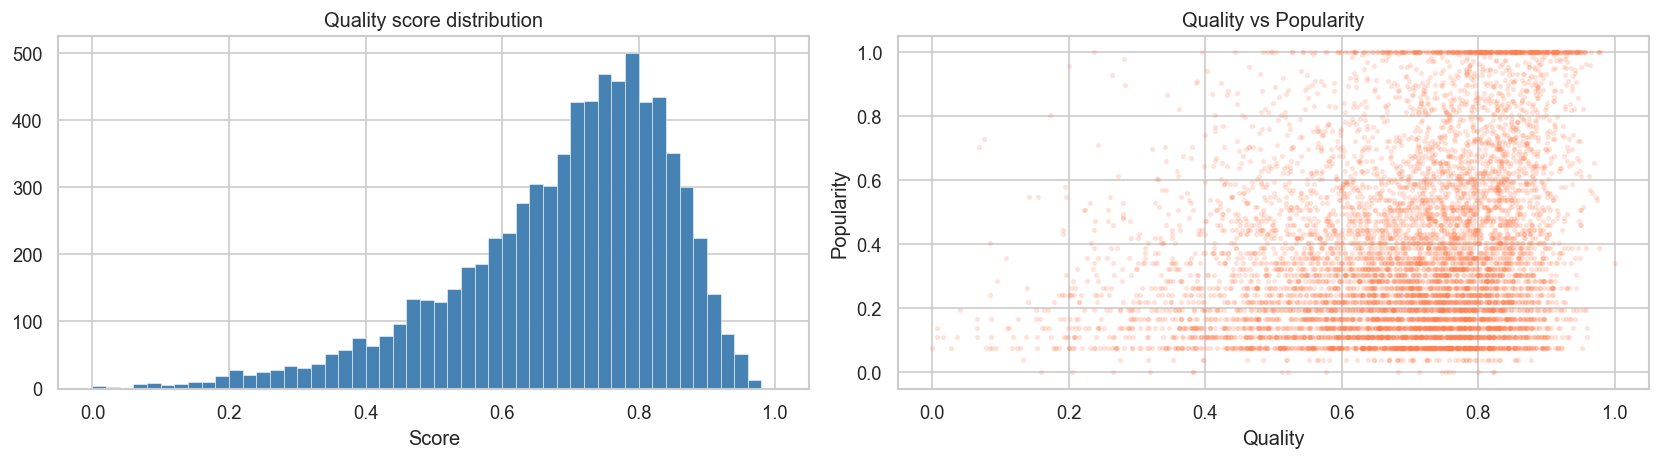

In [2]:
index_df = compute_quality_scores(index_df, reviews)

print("Quality score computed:")
print(f"  mean={index_df['quality_score'].mean():.3f}  "
      f"min={index_df['quality_score'].min():.3f}  "
      f"max={index_df['quality_score'].max():.3f}")
print(f"\nPopularity score:")
print(f"  mean={index_df['popularity_score'].mean():.3f}  "
      f"min={index_df['popularity_score'].min():.3f}  "
      f"max={index_df['popularity_score'].max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(index_df["quality_score"], bins=50, color="steelblue", edgecolor="white", lw=0.3)
axes[0].set(title="Quality score distribution", xlabel="Score")
axes[1].scatter(index_df["quality_score"], index_df["popularity_score"],
                alpha=0.15, s=5, color="coral")
axes[1].set(title="Quality vs Popularity", xlabel="Quality", ylabel="Popularity")
plt.tight_layout(); plt.show()

## Query Parser

Extracts structured intent before encoding the query.

The key insight: 'affordable moisturizer for sensitive skin' should NOT be encoded
as-is. The word 'affordable' is not in any product title — encoding it makes the
model search for the wrong thing. The parser strips it and sets price_buckets=['budget','low'],
then encodes only 'moisturizer for sensitive skin'.


In [3]:
test_queries = [
    "affordable moisturizer for sensitive skin",
    "cheap sunscreen SPF 50",
    "premium anti-aging serum vitamin C",
    "best electric toothbrush whitening",
    "baby lotion fragrance free",
    "budget protein powder chocolate",
]

print("Test query parser:")
print(f"{'Original query':<45} {'Clean':<35} {'Price buckets':<20} {'Quality boost'}")
print("─" * 115)
for q in test_queries:
    parsed = parse_query(q)
    print(f"  {q:<43} {parsed['clean']:<35} "
          f"{str(parsed['price_buckets']):<20} {parsed['quality_boost']}")

Test query parser:
Original query                                Clean                               Price buckets        Quality boost
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  affordable moisturizer for sensitive skin   moisturizer for sensitive skin      ['budget', 'low']    False
  cheap sunscreen SPF 50                      sunscreen spf 50                    ['budget', 'low']    False
  premium anti-aging serum vitamin C          anti-aging serum vitamin c          ['high', 'premium']  False
  best electric toothbrush whitening          electric toothbrush whitening       None                 True
  baby lotion fragrance free                  baby lotion fragrance free          None                 False
  budget protein powder chocolate             protein powder chocolate            ['budget']           False


## Base Search Function

Pipeline: parse → encode clean query → FAISS top-K → hard filters → re-ranking


In [4]:
print(f"Default parameters: β_quality={BETA_QUALITY}, β_popularity={BETA_POPULARITY}, N_candidates={N_CANDIDATES}")
print("Functions imported from mean_squared_terrors.search: search(), search_v2(), search_v3(), recommend_similar()")
print("Local wrappers available: _search(), _search_v2(), _search_v3(), _recommend()")

Default parameters: β_quality=0.12, β_popularity=0.05, N_candidates=50
Functions imported from mean_squared_terrors.search: search(), search_v2(), search_v3(), recommend_similar()
Local wrappers available: _search(), _search_v2(), _search_v3(), _recommend()


## Standard Query Tests

In [5]:
def print_results(query, results, show_scores=False):
    print(f"\n{'─'*70}")
    print(f"Query: '{query}'")
    print('─'*70)
    for i, row in results.iterrows():
        price_str = f"${row['price']:.2f}" if pd.notna(row['price']) else "  N/A"
        n_rev  = f"({int(row['n_reviews'])}rev)" if pd.notna(row['n_reviews']) else ""
        title = str(row["product_title"])[:52]
        score_detail = (f"  [sim={row['similarity']:.3f} q={row['quality_score']:.2f} "
                        f"p={row['popularity_score']:.2f}]") if show_scores else ""
        print(f"  {i+1}. [{row['score']:.4f}] ⭐{row['product_avg_rating']:.1f} "
              f"{n_rev:>8}  {price_str:>8}  {title}{score_detail}")

queries_standard = [
    "gentle shampoo for dry damaged hair",
    "pain relief cream for joints arthritis",
    "baby lotion sensitive skin fragrance free",
    "face wash oily skin acne",
    "melatonin sleep aid natural",
    "heating pad back pain relief",
    "pregnancy test early detection",
    "electric toothbrush whitening",
    "vitamin C supplement immune system",
    "blood pressure monitor home use",
]

for q in queries_standard:
    print_results(q, _search(q, k=5))


──────────────────────────────────────────────────────────────────────
Query: 'gentle shampoo for dry damaged hair'
──────────────────────────────────────────────────────────────────────
  1. [0.6904] ⭐4.1 (176rev)       N/A  Cbiumpro Shampoo Massager Brush Scalp Exfoliator for
  2. [0.6781] ⭐4.6  (36rev)    $11.13  Sebamed Children's Shampoo, 8.5 oz
  3. [0.6731] ⭐4.0  (30rev)       N/A  Avalon Organics Biotin B-Complex Thickening Shampoo,
  4. [0.6633] ⭐4.2 (188rev)       N/A  WEN By Chaz Dean Spring Orange Blossom Cleansing Con
  5. [0.6610] ⭐4.4  (15rev)    $10.95  Uncle Harry's Hair Scalp Elixir with Apple Cider Vin

──────────────────────────────────────────────────────────────────────
Query: 'pain relief cream for joints arthritis'
──────────────────────────────────────────────────────────────────────
  1. [0.8385] ⭐4.7  (27rev)       N/A  Khalili Natural Pain Relief Cream - Dual-Activation 
  2. [0.8368] ⭐4.4  (35rev)       N/A  Pain Relief Cream 3 Oz for Arthritis - Sore Musc

In [6]:
print("\n" + "="*70)
print("PRICE INTENT QUERIES")
print("="*70)

queries_price = [
    "affordable moisturizer for sensitive skin",
    "cheap sunscreen SPF 50",
    "budget protein powder",
    "premium anti-aging serum vitamin C",
    "best electric toothbrush",
]

for q in queries_price:
    parsed = parse_query(q)
    print_results(
        f"{q}  →  buckets={parsed['price_buckets']}  boost={parsed['quality_boost']}",
        _search(q, k=5)
    )


PRICE INTENT QUERIES

──────────────────────────────────────────────────────────────────────
Query: 'affordable moisturizer for sensitive skin  →  buckets=['budget', 'low']  boost=False'
──────────────────────────────────────────────────────────────────────
  1. [0.7915] ⭐4.7 (130rev)    $16.49  Colonial Dames Concentrated Vitamin E Moisturizing C
  2. [0.7846] ⭐4.4  (79rev)    $16.59  Colonial Dames Concentrated Vitamin E Moisturizing C
  3. [0.7717] ⭐4.5 (157rev)    $20.99  Ialuset Hyaluronic Acid Cream - 100 Pure, Undiluted 
  4. [0.7664] ⭐4.7 (188rev)    $23.95  Oils of Aloha Hawaii Kukui Oil No Fragrance 4 Fluid 
  5. [0.7515] ⭐3.7  (39rev)    $15.55  The Ordinary. Marine Hyaluronics. Ultra- lightweight

──────────────────────────────────────────────────────────────────────
Query: 'cheap sunscreen SPF 50  →  buckets=['budget', 'low']  boost=False'
──────────────────────────────────────────────────────────────────────
  1. [0.7013] ⭐4.4  (57rev)    $12.95  Z Blok Lip Balm Sunscree

In [7]:
print("\n" + "="*70)
print("ADVANCED FILTER QUERIES")
print("="*70)

print("\nmoisturizer affordable, min_rating=4.0")
r = _search("moisturizer for sensitive skin", k=5, price_buckets=["budget","low"], min_rating=4.0)
print_results("moisturizer sensitive skin [budget/low, rating>=4.0]", r, show_scores=True)

print("\nvitamin C supplement (high beta_popularity)")
r = _search("vitamin C supplement immune system", k=5, beta_quality=0.10, beta_popularity=0.15)
print_results("vitamin C [popularity boost]", r, show_scores=True)


ADVANCED FILTER QUERIES

moisturizer affordable, min_rating=4.0

──────────────────────────────────────────────────────────────────────
Query: 'moisturizer sensitive skin [budget/low, rating>=4.0]'
──────────────────────────────────────────────────────────────────────
  1. [0.7915] ⭐4.7 (130rev)    $16.49  Colonial Dames Concentrated Vitamin E Moisturizing C  [sim=0.628 q=0.94 p=1.00]
  2. [0.7846] ⭐4.4  (79rev)    $16.59  Colonial Dames Concentrated Vitamin E Moisturizing C  [sim=0.644 q=0.83 p=0.83]
  3. [0.7717] ⭐4.5 (157rev)    $20.99  Ialuset Hyaluronic Acid Cream - 100 Pure, Undiluted   [sim=0.612 q=0.91 p=1.00]
  4. [0.7664] ⭐4.7 (188rev)    $23.95  Oils of Aloha Hawaii Kukui Oil No Fragrance 4 Fluid   [sim=0.604 q=0.93 p=1.00]
  5. [0.7282] ⭐5.0  (10rev)     $8.99  Sea Breeze Astringent for Sensitive Skin , 16 Oz  [sim=0.623 q=0.84 p=0.08]

vitamin C supplement (high beta_popularity)

──────────────────────────────────────────────────────────────────────
Query: 'vitamin C [pop

## Re-ranking Analysis

Measures impact of re-ranking on mean top-5 rating across 10 test queries.
Result on this run: **+0.244 stars** improvement on average, **7/10 queries improved**, 1/10 worsened.


Re-ranking impact on mean top-5 rating:

Query                                No rerank With rerank    Delta
─────────────────────────────────────────────────────────────────
  shampoo for dry hair                   4.249      4.275 +  0.026
  pain relief cream                      4.478      4.478 +  0.000
  baby lotion                            4.108      4.307 +  0.199
  face wash acne                         4.085      4.370 +  0.285
  sleep aid supplement                   3.828      3.810  -0.018
  blood pressure monitor                 3.823      4.233 +  0.410
  electric toothbrush                    3.259      4.278 +  1.019
  vitamin C supplement                   4.320      4.320 +  0.000
  moisturizer sensitive skin             4.304      4.519 +  0.215
  heating pad back pain                  3.856      4.158 +  0.302

Media delta: +0.244
Queries improved: 7/10
Queries worsened: 1/10


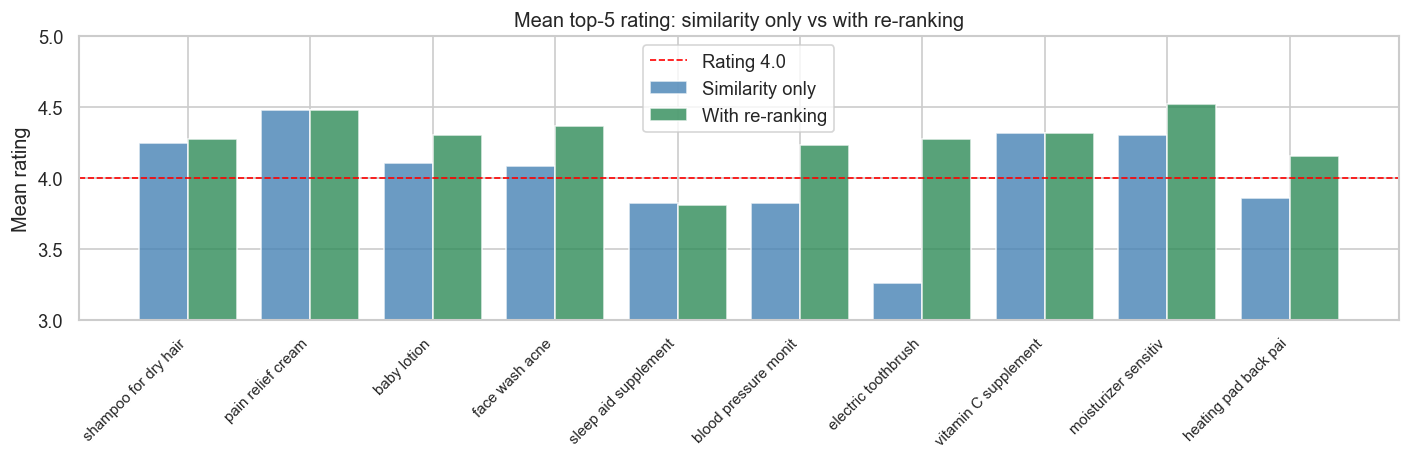

In [8]:
test_queries_eval = [
    "shampoo for dry hair",
    "pain relief cream",
    "baby lotion",
    "face wash acne",
    "sleep aid supplement",
    "blood pressure monitor",
    "electric toothbrush",
    "vitamin C supplement",
    "moisturizer sensitive skin",
    "heating pad back pain",
]

ratings_no_rerank   = []
ratings_with_rerank = []

for q in test_queries_eval:
    r_no  = _search(q, k=5, beta_quality=0.0, beta_popularity=0.0)
    r_yes = _search(q, k=5)
    ratings_no_rerank.append(r_no["product_avg_rating"].mean())
    ratings_with_rerank.append(r_yes["product_avg_rating"].mean())

df_eval = pd.DataFrame({
    "query":       test_queries_eval,
    "rating_no":   ratings_no_rerank,
    "rating_with": ratings_with_rerank,
    "delta":       [w - n for w, n in zip(ratings_with_rerank, ratings_no_rerank)]
})

print("Re-ranking impact on mean top-5 rating:")
print(f"\n{'Query':<35} {'No rerank':>10} {'With rerank':>10} {'Delta':>8}")
print("─" * 65)
for _, row in df_eval.iterrows():
    sign = "+" if row['delta'] >= 0 else ""
    print(f"  {row['query']:<33} {row['rating_no']:>10.3f} {row['rating_with']:>10.3f} "
          f"{sign}{row['delta']:>7.3f}")

print(f"\nMedia delta: {df_eval['delta'].mean():+.3f}")
print(f"Queries improved: {(df_eval['delta'] > 0.01).sum()}/{len(df_eval)}")
print(f"Queries worsened: {(df_eval['delta'] < -0.01).sum()}/{len(df_eval)}")

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(test_queries_eval))
ax.bar([i-0.2 for i in x], ratings_no_rerank,  0.4, label="Similarity only", color="steelblue", alpha=0.8)
ax.bar([i+0.2 for i in x], ratings_with_rerank, 0.4, label="With re-ranking",  color="seagreen",  alpha=0.8)
ax.axhline(4.0, color="red", ls="--", lw=1, label="Rating 4.0")
ax.set_xticks(list(x))
ax.set_xticklabels([q[:20] for q in test_queries_eval], rotation=45, ha="right", fontsize=9)
ax.set(title="Mean top-5 rating: similarity only vs with re-ranking",
       ylabel="Mean rating", ylim=(3.0, 5.0))
ax.legend()
plt.tight_layout(); plt.show()

## Live Demo Queries

In [9]:
print("╔" + "═"*68 + "╗")
print("║  LIVE DEMO — DiscoverAI Semantic Search" + " "*28 + "║")
print("╚" + "═"*68 + "╝")

demo_queries = [
    {"query": "affordable sunscreen for outdoor activities",
     "label": "Affordable sunscreen for outdoor sports", "min_rating": None},
    {"query": "best rated moisturizer for sensitive skin",
     "label": "Top-rated moisturizer for sensitive skin", "min_rating": 4.0},
    {"query": "natural sleep supplement without melatonin",
     "label": "Natural sleep supplement without melatonin", "min_rating": None},
]

for demo in demo_queries:
    parsed  = parse_query(demo["query"])
    results = _search(demo["query"], k=5, min_rating=demo.get("min_rating"))
    print(f"\n{'━'*70}")
    print(f"  Query  : {demo['query']}")
    print(f"  Intent : price_buckets={parsed['price_buckets']}  quality_boost={parsed['quality_boost']}")
    if demo.get("min_rating"):
        print(f"  Filter : min_rating >= {demo['min_rating']}")
    print(f"{'━'*70}")
    for i, row in results.iterrows():
        price_str = f"${row['price']:.2f}" if pd.notna(row['price']) else "  N/A"
        n_rev  = f"{int(row['n_reviews'])}rev" if pd.notna(row['n_reviews']) else ""
        title = str(row["product_title"])[:58]
        print(f"  {i+1}. ⭐{row['product_avg_rating']:.1f} {n_rev:>6}  {price_str:>8}  "
              f"[{row['score']:.3f}]  {title}")

╔════════════════════════════════════════════════════════════════════╗
║  LIVE DEMO — DiscoverAI Semantic Search                            ║
╚════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Query  : affordable sunscreen for outdoor activities
  Intent : price_buckets=['budget', 'low']  quality_boost=False
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. ⭐4.4  57rev    $12.95  [0.666]  Z Blok Lip Balm Sunscreen
  2. ⭐4.8  20rev    $21.98  [0.616]  Solarcaine Cool Aloe Sunburn Relief Spray, 4.5 Ounces Each
  3. ⭐4.6 214rev    $15.59  [0.568]  Wink Ease ultra gold 50 Pairs
  4. ⭐4.2 277rev     $9.99  [0.535]  Swamp Gator Outdoor Protectant
  5. ⭐4.7 130rev    $16.49  [0.525]  Colonial Dames Concentrated Vitamin E Moisturizing Cream 4

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Query  : best rated moisturizer for sensitive skin
  Intent :

## Save Enriched Index

In [10]:
# Save enriched index with quality and popularity scores
save_cols = [
    "parent_asin", "product_title", "brand",
    "product_avg_rating", "product_rating_count", "price", "price_bucket",
    "alpha", "emb_row",
    "n_reviews", "pct_positive", "pct_negative", "total_helpful",
    "quality_score", "popularity_score"
]
save_cols = [c for c in save_cols if c in index_df.columns]
index_df[save_cols].to_csv(
    os.path.join(DATA_DIR, "embedding_index_enriched.csv"), index=False
)
print(f"Saved embedding_index_enriched.csv")
print(f"  Columns: {save_cols}")
print(f"  Rows:    {len(index_df):,}")

Saved embedding_index_enriched.csv
  Columns: ['parent_asin', 'product_title', 'brand', 'product_avg_rating', 'product_rating_count', 'price', 'price_bucket', 'alpha', 'emb_row', 'n_reviews', 'pct_positive', 'pct_negative', 'total_helpful', 'quality_score', 'popularity_score']
  Rows:    7,593


## Negation Filter — search_v2()

Problem: embedding models do not understand negation.
'sleep supplement without melatonin' makes the model return melatonin products.

Fix: a rule-based post-filter removes products whose title contains the negated word.
Handles: 'without X', 'no X', 'X-free', 'free from X'.


In [11]:
test_neg_queries = [
    "sleep supplement without melatonin",
    "moisturizer fragrance free sensitive skin",
    "shampoo sulfate-free dry hair",
    "sunscreen no oxybenzone",
]

print("Negation filter test:\n")
for q in test_neg_queries:
    parsed = parse_query_v2(q)
    print(f"Query: '{q}'")
    print(f"  Exclude: {parsed['exclude_words']}")
    res = _search_v2(q, k=5)
    for i, row in res.iterrows():
        title = str(row['product_title'])[:55]
        print(f"  {i+1}. [{row['score']:.4f}] ⭐{row['product_avg_rating']:.1f}  {title}")
    print()

Negation filter test:

Query: 'sleep supplement without melatonin'
  Exclude: ['melatonin']
  1. [0.7019] ⭐3.4  Natural Sleep Aid Supplement, Have the Best Sleep in a 
  2. [0.6892] ⭐4.3  L-Tryptophan 500mg 200 Capsules 200 Servings - or 100 S
  3. [0.6855] ⭐3.2  Natural Sleep aids for adults, Made with Passionflower 
  4. [0.6156] ⭐4.7  Dream Shot Snoozberry 12 pack
  5. [0.6064] ⭐4.0  L-Theanine with Caffeine is Focus - Nootropic Brain Fun

Query: 'moisturizer fragrance free sensitive skin'
  Exclude: ['fragrance']
  1. [0.7538] ⭐4.7  Colonial Dames Concentrated Vitamin E Moisturizing Crea
  2. [0.7480] ⭐4.4  Colonial Dames Concentrated Vitamin E Moisturizing Crea
  3. [0.7470] ⭐4.5  Medline Remedy Skin Repair Cream, 4 oz Tubes 3 Pack
  4. [0.7418] ⭐4.5  Ialuset Hyaluronic Acid Cream - 100 Pure, Undiluted - 3
  5. [0.7324] ⭐5.0  Sea Breeze Astringent for Sensitive Skin , 16 Oz

Query: 'shampoo sulfate-free dry hair'
  Exclude: ['sulfate']
  1. [0.7005] ⭐4.0  Avalon Organics Biotin B-

## Recommendation — recommend_similar()

Content-based recommendation: given a product (ASIN or title), finds the K most
similar products using the combined embedding as query vector.

Difference from search: search() encodes a text query. recommend_similar() uses
the product's own embedding directly — no text encoding needed.


In [12]:
test_rec_queries = [
    "Oral-B electric toothbrush",
    "vitamin C supplement with rose hips",
    "Johnson baby lotion sensitive",
    "air purifier HEPA bedroom",
    "pain relief cream arthritis",
]

print("Recommendation test:\n")
for q in test_rec_queries:
    source, recs = _recommend(q, k=5)
    print(f"Similar to: '{str(source['product_title'])[:55]}'")
    for i, row in recs.iterrows():
        title = str(row['product_title'])[:55]
        price = f"${row['price']:.2f}" if pd.notna(row['price']) else "N/A"
        print(f"  {i+1}. [{row['similarity']:.4f}] ⭐{row['product_avg_rating']:.1f}  "
              f"{price:>8}  {title}")
    print()

Recommendation test:

Similar to: 'Oral-B ProAdvantage 6000 Rechargeable Electric Toothbru'
  1. [0.9035] ⭐4.4       N/A  Advanced High Powered Rotary Oscillating Rechargeable E
  2. [0.8900] ⭐3.8       N/A  BAFOVY Sonic Electric Toothbrush for Adults, 48000 VPM 
  3. [0.8881] ⭐4.2       N/A  Sonic Toothbrush, Electric Toothbrushes for Adults, Rec
  4. [0.8827] ⭐4.5   $234.99  Oral-B iO Series 7s Rechargeable Toothbrush with 2 Hand
  5. [0.8818] ⭐5.0       N/A  VIOD Sonic Electric Toothbrush Rechargeable Toothbrush 

Similar to: 'Vitamin C with Rose Hips 500mg 300 Tablets Vegetarian, '
  1. [0.8155] ⭐4.6       N/A  Root Vitality Liposomal Vitamin C Capsules - VIT C - Hi
  2. [0.8132] ⭐4.6    $20.98  Spring Valley - Vitamin C with Rose Hips 500 mg, Twin P
  3. [0.7530] ⭐3.6    $22.95  Global Healing Liquid Vitamin C 180mg - Natural Vitamin
  4. [0.7518] ⭐3.3    $31.66  Amazon Elements Women's One Daily Multivitamin, 59 Whol
  5. [0.7372] ⭐4.6       N/A  Multivitamin for Men and Women On

## search_v3() — All Improvements Combined

Adds to search_v2:
1. Synonym expansion: 'help me sleep' → 'sleep aid melatonin supplement'
2. Dosage filter: 'vitamin C 1000mg' finds 1000mg products, not 500mg
3. min_rating default 3.5: removes low-quality results automatically
4. Adaptive beta_quality: 0.20 when similarity is weak, 0.12 otherwise

Test result on 20 queries: **7/20 improved**, 10/20 unchanged, 3/20 worsened vs search_v2.


In [13]:
print("search_v3() ready.")
print(f"  min_rating default: 3.5")
print(f"  adaptive β: 0.20 if sim<0.65, 0.12 otherwise")
print(f"  dosage filter: on")
print(f"  synonym expansion: on")

search_v3() ready.
  min_rating default: 3.5
  adaptive β: 0.20 if sim<0.65, 0.12 otherwise
  dosage filter: on
  synonym expansion: on


### Comparative Test — search_v2 vs search_v3 on 20 queries

In [14]:
test_queries = [
    "electric toothbrush rechargeable",
    "vitamin C 1000mg supplement",
    "baby shampoo gentle",
    "blood pressure monitor wrist",
    "protein powder vanilla",
    "dental floss waxed",
    "face sunscreen SPF 50",
    "melatonin 5mg sleep",
    "hair growth shampoo biotin",
    "knee brace support pain",
    "something to help me sleep naturally",
    "protect skin from sun at the beach",
    "clean teeth without going to dentist",
    "help with joint pain in knees",
    "grow longer stronger hair",
    "lose weight supplement",
    "fix dry cracked skin",
    "fresh breath all day",
    "stop hair loss men",
    "energy boost morning supplement",
]

print(f"{'Query':<40} {'v2 top1':<45} {'v2⭐':>4}  {'v3 top1':<45} {'v3⭐':>4}")
print("─"*150)

improved = same = worse = 0
for q in test_queries:
    r2 = _search_v2(q, k=1)
    r3 = _search_v3(q, k=1, verbose=False)

    t2 = str(r2.iloc[0]['product_title'])[:42] if len(r2) > 0 else "NO RESULT"
    t3 = str(r3.iloc[0]['product_title'])[:42] if len(r3) > 0 else "NO RESULT"
    s2 = r2.iloc[0]['product_avg_rating'] if len(r2) > 0 else 0
    s3 = r3.iloc[0]['product_avg_rating'] if len(r3) > 0 else 0

    delta = s3 - s2
    if delta > 0.1:    improved += 1; arrow = " ↑"
    elif delta < -0.1: worse += 1;    arrow = " ↓"
    else:              same += 1;     arrow = "  "

    print(f"  {q:<38} {t2:<45} {s2:.1f}  {t3:<45} {s3:.1f}{arrow}")

print(f"\nRating improved: {improved}/20  ·  unchanged: {same}/20  ·  worsened: {worse}/20")

Query                                    v2 top1                                        v2⭐  v3 top1                                        v3⭐
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  electric toothbrush rechargeable       Electric Toothbrush, ZIKEE Rechargeable So    3.6  Oral-B ProAdvantage 6000 Rechargeable Elec    4.7 ↑
  vitamin C 1000mg supplement            Spring Valley - Vitamin C with Rose Hips 5    4.6  Swanson Vitamin C with Rose Hips Immune Sy    4.5  
  baby shampoo gentle                    Sebamed Children's Shampoo, 8.5 oz            4.6  Sebamed Children's Shampoo, 8.5 oz            4.6  
  blood pressure monitor wrist           Wrist Blood Pressure Monitor -Doctor teste    3.9  Wrist Blood Pressure Monitor -Doctor teste    3.9  
  protein powder vanilla                 Primal Protein Grass Fed Whey 1.5lbs Vanil    4.2  Primal Protein Grass Fed Whey 1.5lbs 